# The four modalities, in plain terms

Every model in this project eats **blocks**: 2-D arrays of shape `(channels,
length)`, one per gene per modality. All four modalities describe the *same
isolate*; they differ in what they measure.

| modality | in one sentence | channels | length | comes from |
|---|---|---|---|---|
| **dna** | which letter sits at each position of the gene | 5 — A, C, T, G, gap | the gene, in bases | aligned gene FASTA |
| **protein** | which amino acid each codon codes for | 20 — one per amino acid | the gene, in codons | the DNA, translated |
| **biophysical** | how big / charged / greasy each amino acid is | 3 — weight, charge, water-hating | the gene, in codons | the amino acids, looked up |
| **regulatory** | the promoter — the switch upstream that sets how much protein gets made | 5 — A, C, T, G, gap | the upstream window | a separate promoter FASTA |

The first three are three readings of **the same DNA**: letters → amino acids →
properties of those amino acids. The fourth is a **different stretch of DNA**
entirely — it sits *before* the gene and is not part of it.

In [1]:
# this notebook lives in notebooks/; put the project root on the path
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from bigtb_ref import REAL_GENOTYPE_DIR, REAL_PHENOTYPE_CSV, REAL_REGULATORY_DIR

DRUG = "ISONIAZID"          # the example drug used throughout

# one block per LOCUS (not per modality) so each gene stays visible on its own
data = load_dataset(DRUG, ["dna", "protein", "biophysical", "regulatory"],
                    REAL_GENOTYPE_DIR, REAL_PHENOTYPE_CSV,
                    regulatory_dir=REAL_REGULATORY_DIR,
                    per_modality_branch=False)

print(f"{DRUG}: {data.n:,} isolates,  labels {data.class_counts()}")
print(f"genes: {data.gene_order}")

ISONIAZID: 17,942 isolates,  labels {'R': 5825, 'S': 11611, 'missing': 506}
genes: ['inhA', 'katG']


## What actually gets loaded

One row per block. `dna` / `protein` / `biophysical` repeat per **gene**, and
`regulatory` repeats per **promoter window** — by default one per gene, because
the region list is intersected with the loci actually loaded.

In [2]:
rows = [{"block": b.name, "modality": b.modality,
         "channels": b.array.shape[1], "length": b.array.shape[2],
         "dtype": str(b.array.dtype), "what it is": b.note[:60]}
        for b in data.blocks]
blocks = pd.DataFrame(rows)
print(f"{len(blocks)} blocks total\n")
display(blocks)

8 blocks total



,block,modality,channels,length,dtype,what it is
0,dna:inhA,dna,5,910,float32,locus inhA
1,dna:katG,dna,5,2488,float32,locus katG
2,protein:inhA,protein,20,269,float32,"gene inhA, CDS window translated + left-aligned"
3,protein:katG,protein,20,741,float32,"gene katG, CDS window translated + left-aligned"
4,biophysical:inhA,biophysical,3,269,float32,"gene inhA, CDS window, z-scored per property"
5,biophysical:katG,biophysical,3,741,float32,"gene katG, CDS window, z-scored per property"
6,regulatory:inhA,regulatory,5,879,float32,"WHO Table 22 upstream region inhA (1-813, TSS ..."
7,regulatory:katG,regulatory,5,642,float32,"WHO Table 22 upstream region katG (1-532, TSS ..."


## The same gene, three ways

`katG` below. Same isolate, same gene — only the reading changes. Note the
lengths: protein and biophysical are a third of the DNA length, because three
DNA letters make one amino acid.

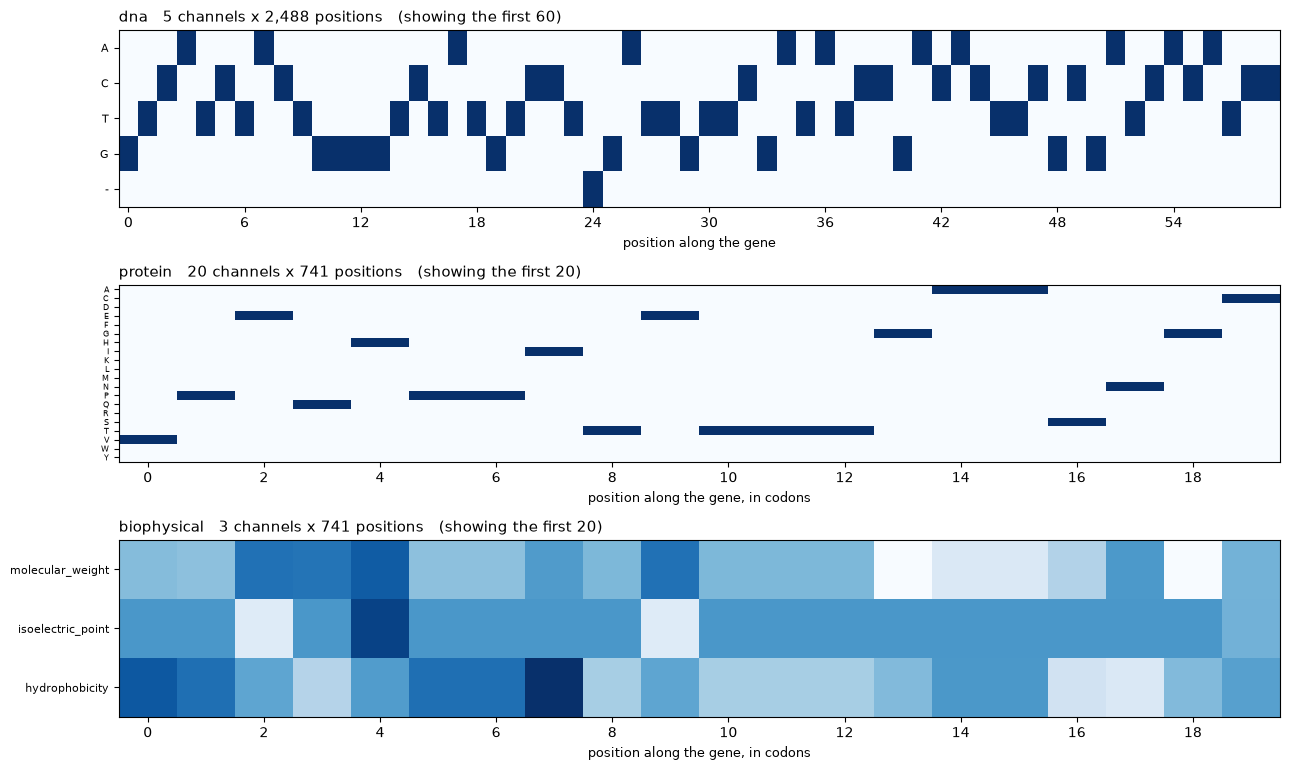

dna           5 channels x 2,488 positions
protein      20 channels x   741 positions
biophysical   3 channels x   741 positions


In [3]:
GENE = "katG"
iso = 0                                   # which isolate to draw
W = 60                                    # how many positions to show

picks = [(m, next(b for b in data.blocks if b.name == f"{m}:{GENE}"))
         for m in ("dna", "protein", "biophysical")
         if any(b.name == f"{m}:{GENE}" for b in data.blocks)]

from matplotlib.ticker import MaxNLocator
fig, axes = plt.subplots(len(picks), 1, figsize=(13, 2.6 * len(picks)))
for ax, (mod, b) in zip(np.atleast_1d(axes), picks):
    arr = b.array[iso].astype(float)
    n = W if mod == "dna" else W // 3     # same stretch of gene in both units
    ax.imshow(arr[:, :n], aspect="auto", cmap="Blues", interpolation="nearest")
    ax.set_yticks(range(arr.shape[0]), b.channel_names,
                  fontsize=5.5 if arr.shape[0] > 10 else 8)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_title(f"{mod}   {arr.shape[0]} channels x {arr.shape[1]:,} positions"
                 f"   (showing the first {n})", loc="left", fontsize=11)
    ax.set_xlabel("position along the gene" if mod == "dna"
                  else "position along the gene, in codons", fontsize=9)
fig.tight_layout()
plt.show()

for mod, b in picks:
    print(f"{mod:<12} {b.array.shape[1]:>2} channels x {b.array.shape[2]:>5,} positions")

### Reading the picture

- **dna** — exactly one dark square per column: the letter at that base. The
  `-` row is a gap in the alignment.
- **protein** — again one dark square per column, but out of 20 rows, and there
  are a third as many columns.
- **biophysical** — no one-hot at all. Three continuous rows: each amino acid
  replaced by its weight, charge and water-hating score (z-scored). This is the
  modality the whole project is about.

## The regulatory modality is a *different* piece of DNA

It is not part of the gene. It is the window immediately **upstream**, where the
cell decides how much protein to make. A mutation there changes the *amount* of
a normal protein, rather than changing the protein itself — which is exactly how
isoniazid resistance often works.

By default you get **one region per loaded locus**. WHO's candidate list for a
drug is much longer (12 promoters for INH, against 2 coding loci) and most of
those belong to genes whose CDS is never loaded, so the default keeps only the
promoters of genes the model already sees. Pass `all_regulatory=True`
(`--all-regulatory` on the runners) for the full WHO set, or name regions
explicitly with `regulatory_loci=[...]`.

loaded (2, one per locus):
   regulatory:inhA          5 x   879   WHO Table 22 upstream region inhA (1-813, TSS 1673440)
   regulatory:katG          5 x   642   WHO Table 22 upstream region katG (1-532, TSS 2156592)

WHO lists 13 candidate promoters for ISONIAZID; the 11 not loaded belong to genes whose CDS we do not load:
   ['furA', 'ahpC', 'dnaA', 'Rv0010c', 'mshA', 'hadA', 'Rv1129c', 'Rv1258c', 'ndh', 'Rv2752c', 'glpK']
   (--all-regulatory loads them too)


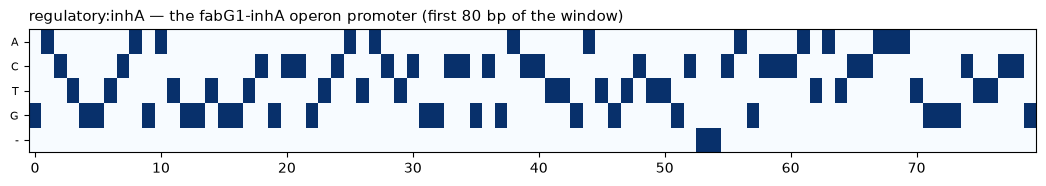

In [4]:
from datasets import DRUG_TO_REGULATORY

reg = [b for b in data.blocks if b.modality == "regulatory"]
print(f"loaded ({len(reg)}, one per locus):")
for b in reg:
    print(f"   {b.name:<24} {b.array.shape[1]} x {b.array.shape[2]:>5}   {b.note[:70]}")
full = DRUG_TO_REGULATORY[DRUG]
print(f"\nWHO lists {len(full)} candidate promoters for {DRUG}; the "
      f"{len(full) - len(reg)} not loaded belong to genes whose CDS we do not "
      f"load:\n   {[r for r in full if f'regulatory:{r}' not in [b.name for b in reg]]}")
print("   (--all-regulatory loads them too)")

# The famous one: WHO files the fabG1-inhA operon promoter under "inhA", keyed to
# fabG1's own start, so `regulatory:inhA` is the window carrying the c-15t variant.
inha = next((b for b in reg if b.name == "regulatory:inhA"), None)
if inha is not None:
    fig, ax = plt.subplots(figsize=(13, 1.6))
    ax.imshow(inha.array[iso, :, :80].astype(float), aspect="auto",
              cmap="Blues", interpolation="nearest")
    ax.set_yticks(range(5), inha.channel_names, fontsize=8)
    ax.set_title("regulatory:inhA — the fabG1-inhA operon promoter "
                 "(first 80 bp of the window)", loc="left", fontsize=11)
    plt.show()

## Which genes each modality covers

The gene modalities follow the drug's resistance genes. The regulatory modality
follows the WHO promoter list, which is a different, longer set — so the two do
not line up one-to-one, and a locus can appear in one and not the other.

In [5]:
cov = (blocks.assign(gene=blocks.block.str.split(":").str[-1])
              .pivot_table(index="gene", columns="modality", values="length",
                           aggfunc="first"))
cov = cov.reindex(columns=[c for c in ("dna", "protein", "biophysical", "regulatory")
                           if c in cov.columns])
display(cov.fillna("—"))
print("numbers are block LENGTHS; — means that modality has no block for that gene")

modality,dna,protein,biophysical,regulatory
gene,,,,
inhA,910,269,269,879
katG,2488,741,741,642


numbers are block LENGTHS; — means that modality has no block for that gene


## Labels

One label per isolate per drug: resistant, susceptible, or missing. Missing rows
are dropped before training, so only the first two counts matter.

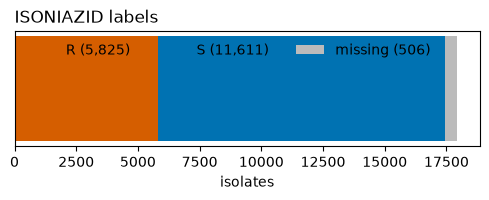

In [6]:
counts = data.class_counts()
fig, ax = plt.subplots(figsize=(6, 1.5))
left = 0
for name, colour in [("R", "#D55E00"), ("S", "#0072B2"), ("missing", "#BBBBBB")]:
    v = counts[name]
    ax.barh([0], [v], left=left, color=colour, label=f"{name} ({v:,})")
    left += v
ax.set_yticks([]); ax.set_xlabel("isolates"); ax.legend(ncol=3, frameon=False)
ax.set_title(f"{DRUG} labels", loc="left")
plt.show()

---

**In one line:** a model sees one `(channels, length)` block per gene per
modality — DNA letters, the amino acids they code for, three numbers describing
each amino acid, and separately the promoter switch upstream of the gene.

To try another drug, change `DRUG` in the setup cell. For how these blocks are
wired into each network, see `scripts/trace_models.py`, which pushes one real
isolate through every model and diagrams every shape.